In [1]:
from __future__ import annotations

import argparse
import struct
from pathlib import Path
from scipy.signal import correlate, correlation_lags
import numpy as np
import matplotlib.pyplot as plt

In [2]:

def read_raw_frame(
    path: Path,
    spectra_per_frame: int,
    channels: int,
    elements: int,
) -> tuple[np.memmap, int, int]:
    """Return frame memmap, FPGA sequence number and metadata size."""
    with path.open("rb") as stream:
        size_bytes = stream.read(4)
        if len(size_bytes) != 4:
            raise ValueError(f"{path}: missing metadata-size word")
        metadata_size = struct.unpack("=I", size_bytes)[0]
        metadata = stream.read(metadata_size)
        if len(metadata) != metadata_size:
            raise ValueError(f"{path}: truncated metadata")

    # chartsMetadataFormat starts with int32 frame_counter, native padding,
    # int64 fpga_seq_num, then int32 time_downsampling_fpga.
    fpga_seq = struct.unpack_from("@iq", metadata, 0)[1] if metadata_size >= 16 else -1
    data_offset = 4 + metadata_size
    expected_data_size = spectra_per_frame * channels * elements
    actual_data_size = path.stat().st_size - data_offset
    if actual_data_size != expected_data_size:
        raise ValueError(
            f"{path}: expected {expected_data_size} data bytes after metadata, "
            f"found {actual_data_size}"
        )

    frame = np.memmap(
        path,
        dtype=np.uint8,
        mode="r",
        offset=data_offset,
        shape=(spectra_per_frame, channels, elements),
        order="C",
    )
    return frame, fpga_seq, metadata_size



def decode_int4x2(values: np.ndarray, iq_order: str) -> np.ndarray:
    """Decode signed int4x2 bytes into complex64 values."""
    low = (values & 0x0F).astype(np.int8)
    high = ((values >> 4) & 0x0F).astype(np.int8)
    low = ((low << 4) >> 4).astype(np.float32)
    high = ((high << 4) >> 4).astype(np.float32)

    if iq_order == "ri":
        real, imag = low, high
    else:
        real, imag = high, low
    return real + 1j * imag


def read_raw_frame(
    path: Path,
    spectra_per_frame: int,
    channels: int,
    elements: int,
) -> tuple[np.memmap, int, int]:
    """Return frame memmap, FPGA sequence number and metadata size."""
    with path.open("rb") as stream:
        size_bytes = stream.read(4)
        if len(size_bytes) != 4:
            raise ValueError(f"{path}: missing metadata-size word")
        metadata_size = struct.unpack("=I", size_bytes)[0]
        metadata = stream.read(metadata_size)
        if len(metadata) != metadata_size:
            raise ValueError(f"{path}: truncated metadata")

    # chartsMetadataFormat starts with int32 frame_counter, native padding,
    # int64 fpga_seq_num, then int32 time_downsampling_fpga.
    fpga_seq = struct.unpack_from("@iq", metadata, 0)[1] if metadata_size >= 16 else -1
    data_offset = 4 + metadata_size
    expected_data_size = spectra_per_frame * channels * elements
    actual_data_size = path.stat().st_size - data_offset
    if actual_data_size != expected_data_size:
        raise ValueError(
            f"{path}: expected {expected_data_size} data bytes after metadata, "
            f"found {actual_data_size}"
        )

    frame = np.memmap(
        path,
        dtype=np.uint8,
        mode="r",
        offset=data_offset,
        shape=(spectra_per_frame, channels, elements),
        order="C",
    )
    return frame, fpga_seq, metadata_size


DEFAULT_SPECTRA_PER_FRAME = 15360
DEFAULT_CHANNELS = 336
DEFAULT_ELEMENTS = 64
def physical_antenna_to_element(antenna: int) -> int:
    """Map physical antenna 0..63 to the descending RFSoC output E index."""
    if not 0 <= antenna < DEFAULT_ELEMENTS:
        raise ValueError(f"antenna must be in [0, 63], got {antenna}")
    return DEFAULT_ELEMENTS - 1 - antenna



In [3]:
def plot_raw_voltage_preview(
    files: list[Path],
    spectra_per_frame: int,
    channels: int,
    elements: int,
    preview_element: int,
    iq_order: str
) -> None:
    """Plot a time-integrated raw voltage preview for one selected antenna."""
    try:
        import matplotlib.pyplot as plt
    except ImportError as error:
        raise SystemExit("matplotlib is required for plotting; use --no-plot for NPZ only") from error

    integrated_intensity = np.zeros(channels, dtype=np.float64)
    total_spectra = 0

    for path in files:
        frame, _, _ = read_raw_frame(path, spectra_per_frame, channels, elements)
        for start in range(0, spectra_per_frame, 2048):
            stop = min(start + 2048, spectra_per_frame)
            voltage = decode_int4x2(np.asarray(frame[start:stop, :, preview_element]), iq_order)
            intensity = voltage.real**2 + voltage.imag**2
            integrated_intensity += np.sum(intensity, axis=0, dtype=np.float64)
            total_spectra += voltage.shape[0]
        del frame

    if total_spectra <= 0:
        raise SystemExit("No spectra available for raw preview")

    mean_intensity = integrated_intensity / total_spectra

    with np.errstate(divide="ignore"):
        mean_intensity_db = 10.0 * np.log10(mean_intensity)

    mean_intensity_db = np.nan_to_num(
        mean_intensity_db,
        nan=-60.0,
        neginf=-60.0,
    )
    mean_intensity_db = np.maximum(mean_intensity_db, -60.0)
    channels_axis = np.arange(channels)

    figure, axis = plt.subplots(figsize=(11, 4.5))
    axis.plot(channels_axis, mean_intensity_db, linewidth=0.9)
    axis.set_xlabel("Coarse-frequency channel")
    axis.set_ylabel("Mean intensity [dB]")
    axis.set_title(f"Time-integrated raw voltage preview, antenna E={preview_element}")
    axis.grid(alpha=0.25)
    figure.tight_layout()
    plt.show()



def plot_time_lag_xcorrelation(
    files: list[Path],
    spectra_per_frame: int,
    channels: int,
    elements: int,
    element_a: int,
    element_b: int,
    iq_order: str,
    chunk_spectra: int,
    handler: int,
    max_lag_spectra: int,
    spectra_per_second: float,
    output_path: Path,
) -> None:


    import matplotlib.pyplot as plt

    if spectra_per_second <= 0:
        raise ValueError("spectra_per_second must be positive")
    if max_lag_spectra < 0:
        raise ValueError("max_lag_spectra must be non-negative")
    if chunk_spectra <= 0:
        raise ValueError("chunk_spectra must be positive")

    cross_sum = np.zeros(channels, dtype=np.complex128)
    total_spectra = 0

    for path in files:
        frame, _, _ = read_raw_frame(
            path, spectra_per_frame, channels, elements
        )

        for start in range(0, spectra_per_frame, chunk_spectra):
            stop = min(start + chunk_spectra, spectra_per_frame)

            voltage_a = decode_int4x2(
                np.asarray(frame[start:stop, :, element_a]), iq_order
            )
            voltage_b = decode_int4x2(
                np.asarray(frame[start:stop, :, element_b]), iq_order
            )

            cross_sum += np.sum(
                voltage_a * np.conj(voltage_b),
                axis=0,
                dtype=np.complex128,
            )
            total_spectra += voltage_a.shape[0]

        del frame

    visibility = cross_sum / total_spectra

    channel_width_hz = 300e3
    n_fft = 2**15

    delay_axis_s = np.fft.fftshift(
        np.fft.fftfreq(n_fft, d=channel_width_hz)
    )
    delay_response = np.fft.fftshift(
        np.fft.fft(visibility, n=n_fft)
    )


    global_channels = handler * channels + np.arange(channels)
    frequencies_hz = 300e6 + global_channels * channel_width_hz
    delay_axis_ns = delay_axis_s * 1e9

    peak_index = np.argmax(np.abs(delay_response))
    tau_ns = delay_axis_ns[peak_index]
    print(f"Peak Amplitude: {np.abs(delay_response[peak_index])} (handler {handler}, antennas E={element_a} vs E={element_b})")
    print(f"Peak delay: {tau_ns} ns (handler {handler}, antennas E={element_a} vs E={element_b})")

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(delay_axis_ns, np.abs(delay_response))
    ax.axvline(
        tau_ns,
        color="red",
        linestyle="--",
        label=f"Delay = {tau_ns:.2f} ns",
    )
    ax.set_xlabel("Delay [ns]")
    ax.set_ylabel(r"$|R_{ab}(\tau)|$")
    ax.set_title(
        f"Delay spectrum Cross Correlation: Antenna E={element_a} vs E={element_b}, handler {handler}"
    )
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

def plot_complex_visibility(
    files,
    spectra_per_frame,
    channels,
    elements,
    element_a,
    element_b,
    iq_order,
    chunk_spectra,
    handler,
    tau_ns,
    freq0_mhz=300.0,
    channel_width_mhz=0.3
):
    cross_sum = np.zeros(channels, dtype=np.complex128)
    total_spectra = 0

    for path in files:
        frame, _, _ = read_raw_frame(
            path,
            spectra_per_frame,
            channels,
            elements,
        )

        for start in range(0, spectra_per_frame, chunk_spectra):
            stop = min(start + chunk_spectra, spectra_per_frame)

            voltage_a = decode_int4x2(
                np.asarray(frame[start:stop, :, element_a]),
                iq_order,
            ).astype(np.complex128)

            voltage_b = decode_int4x2(
                np.asarray(frame[start:stop, :, element_b]),
                iq_order,
            ).astype(np.complex128)

            cross_sum += np.sum(
                voltage_a * np.conj(voltage_b),
                axis=0,
            )


            total_spectra += voltage_a.shape[0]

        del frame

    visibility = cross_sum / total_spectra

    magnitude = np.abs(visibility)
    real_part = np.real(visibility)
    imag_part = np.imag(visibility)
    phase_deg = (np.angle(visibility))


    global_channels = (
        handler * channels + np.arange(channels)
    )

    frequency_mhz = (
        freq0_mhz
        + global_channels * channel_width_mhz
    )

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(12, 9),
        sharex=True,
    )

    axes[0].plot(
        frequency_mhz,
        magnitude,
        linewidth=0.9,
    )
    axes[0].set_ylabel(r"$|\langle V_aV_b^*\rangle_t|$")
    axes[0].set_title(
        f"Complex visibility: Antenna E={element_a} vs E={element_b}, handler {handler}"
    )

    axes[0].grid(alpha=0.25)
    # Plot on rad
    axes[1].plot(
        frequency_mhz,
        phase_deg,
        linewidth=0.9,
    )
    axes[1].set_ylabel("Phase [rad]")
    axes[1].set_ylim(-1.5*np.pi, 1.5*np.pi)
    axes[1].grid(alpha=0.25)

    axes[2].plot(
        frequency_mhz,
        real_part,
        linewidth=0.9,
    )
    axes[2].set_xlabel("Frequency [MHz]")
    axes[2].set_ylabel("Real part")
    axes[2].grid(alpha=0.25)

    axes[3].plot(
        frequency_mhz,
        imag_part,
        linewidth=0.9,
    )
    axes[3].set_xlabel("Frequency [MHz]")
    axes[3].set_ylabel("Imaginary part")
    axes[3].grid(alpha=0.25)

    fig.tight_layout()
    plt.show()


    # Corregimos delay con el valor de tau_ns, para que la fase sea plana

    if tau_ns != None:
        delay_correction = np.exp(
            -2j * np.pi * frequency_mhz * 1e6 * tau_ns * 1e-9
        )
        visibility_corrected = visibility * delay_correction

        magnitude_corrected = np.abs(visibility_corrected)
        phase_deg_corrected = (np.angle(visibility_corrected))
        real_part_corrected = np.real(visibility_corrected)
        imag_part_corrected = np.imag(visibility_corrected)

        fig, axes = plt.subplots(
            4,
            1,
            figsize=(12, 9),
            sharex=True,
        )

        axes[0].plot(
            frequency_mhz,
            magnitude_corrected,
            linewidth=0.9,
        )
        axes[0].set_ylabel(r"$|\langle V_aV_b^*\rangle_t|$")
        axes[0].set_title(
            f"Complex visibility (delay-corrected): Antenna E={element_a} vs E={element_b}, handler {handler}"
        )
        axes[0].grid(alpha=0.25)
        # Plot on rad
        axes[1].plot(
            frequency_mhz,
            phase_deg_corrected,
            linewidth=0.9,
        )
        axes[1].set_ylabel("Phase [rad]")
        axes[1].set_ylim(-1.5*np.pi, 1.5*np.pi)
        axes[1].grid(alpha=0.25)    
        
        axes[2].plot(
            frequency_mhz,
            real_part_corrected,
            linewidth=0.9,
        )
        axes[2].set_xlabel("Frequency [MHz]")
        axes[2].set_ylabel("Real part")
        axes[2].grid(alpha=0.25)

        axes[3].plot(
            frequency_mhz,
            imag_part_corrected,
            linewidth=0.9,
        )

        axes[3].set_ylabel("Imaginary part")
        axes[3].grid(alpha=0.25)

        channel_width_hz = 300e3
        n_fft = 2**15

        delay_axis_s = np.fft.fftshift(
            np.fft.fftfreq(n_fft, d=channel_width_hz)
        )
        delay_response = np.fft.fftshift(
            np.fft.fft(visibility_corrected, n=n_fft)
        )


        global_channels = handler * channels + np.arange(channels)
        frequencies_hz = 300e6 + global_channels * channel_width_hz
        delay_axis_ns = delay_axis_s * 1e9

        peak_index = np.argmax(np.abs(delay_response))
        tau_ns = delay_axis_ns[peak_index]
        print(f"Peak Amplitude: {np.abs(delay_response[peak_index])} (handler {handler}, antennas E={element_a} vs E={element_b})")

        print(f"Peak delay: {tau_ns} ns (handler {handler}, antennas E={element_a} vs E={element_b})")

        fig, ax = plt.subplots(figsize=(11, 4.5))
        ax.plot(delay_axis_ns, np.abs(delay_response))
        ax.axvline(
            tau_ns,
            color="red",
            linestyle="--",
            label=f"Delay = {tau_ns:.2f} ns",
        )
        ax.set_xlabel("Delay [ns]")
        ax.set_ylabel(r"$|R_{ab}(\tau)|$")
        ax.set_title(
            f"Delay spectrum Cross Correlation: Antenna E={element_a} vs E={element_b}, handler {handler}"
        )
        ax.grid(alpha=0.25)
        ax.legend()
        plt.show()



In [6]:
path = Path("/data/same_lenght_cable_take2/")
antenna_a = 0
antenna_b = 32
files = sorted(path.glob("*.bin"))
element_a = physical_antenna_to_element(antenna_a)
element_b = physical_antenna_to_element(antenna_b)

cross_sum = np.zeros(672, dtype=np.complex128)

# plot_raw_voltage_preview(
#     files=files,
#     spectra_per_frame=DEFAULT_SPECTRA_PER_FRAME,
#     channels=DEFAULT_CHANNELS,
#     elements=DEFAULT_ELEMENTS,
#     preview_element=element_a,
#     iq_order="ri"
# )
# plot_raw_voltage_preview(
#     files=files,
#     spectra_per_frame=DEFAULT_SPECTRA_PER_FRAME,
#     channels=DEFAULT_CHANNELS,
#     elements=DEFAULT_ELEMENTS,
#     preview_element=element_b,
#     iq_order="ri"
#)



In [ ]:
from dataclasses import dataclass

@dataclass(frozen=True)
class FrameGroup:
    """A time-aligned interval backed by one file from each selected handler."""

    paths: tuple[Path, ...]
    fpga_start: int
    handler_offsets: tuple[int, ...]
    spectra: int

def endian_prefix(name: str) -> str:
    return {"native": "=", "little": "<", "big": ">"}[name]

def candidate_files(args: argparse.Namespace, handler: int) -> list[Path]:
    """Return sorted raw files for one handler before time selection."""
    if args.pattern:
        if args.handler == "both" and "{handler}" not in args.pattern:
            raise SystemExit(
                "With --handler both, --pattern must contain the {handler} placeholder"
            )
        pattern = args.pattern.format(handler=handler)
    else:
        pattern = f"*network_{handler}_*.bin"

    files = sorted(args.data_dir.glob(pattern))
    if not files:
        raise SystemExit(f"No handler {handler} files matched {args.data_dir / pattern}")
    return files


def select_file_groups(
    args: argparse.Namespace,
) -> tuple[tuple[int, ...], list[FrameGroup]]:
    """Select one handler or align both handlers by overlapping FPGA intervals."""
    handlers = (0, 1) if args.handler == "both" else (int(args.handler),)
    files_by_handler = {handler: candidate_files(args, handler) for handler in handlers}

    if len(handlers) == 1:
        files = files_by_handler[handlers[0]]
        if args.file_count > 0:
            files = (
                files[: args.file_count]
                if args.file_position == "first"
                else files[-args.file_count :]
            )
        groups: list[FrameGroup] = []
        for path in files:
            fpga_seq, _, _ = read_raw_metadata(path, "native")
            if fpga_seq < 0:
                raise SystemExit(f"Cannot index {path}: metadata has no FPGA sequence number")
            groups.append(
                FrameGroup(
                    paths=(path,),
                    fpga_start=fpga_seq,
                    handler_offsets=(0,),
                    spectra=args.spectra_per_frame,
                )
            )
        return handlers, groups

    entries_by_handler: dict[int, list[tuple[int, Path]]] = {}
    for handler in handlers:
        entries: list[tuple[int, Path]] = []
        seen_sequences: dict[int, Path] = {}
        for path in files_by_handler[handler]:
            fpga_seq, _, _ = read_raw_metadata(path, "native")
            if fpga_seq < 0:
                raise SystemExit(f"Cannot align {path}: metadata has no FPGA sequence number")
            if fpga_seq in seen_sequences:
                raise SystemExit(
                    f"Duplicate FPGA sequence {fpga_seq} for handler {handler}: "
                    f"{seen_sequences[fpga_seq]} and {path}"
                )
            seen_sequences[fpga_seq] = path
            entries.append((fpga_seq, path))
        entries_by_handler[handler] = sorted(entries)

    entries_0 = entries_by_handler[handlers[0]]
    entries_1 = entries_by_handler[handlers[1]]
    groups = []
    index_0 = 0
    index_1 = 0
    while index_0 < len(entries_0) and index_1 < len(entries_1):
        start_0, path_0 = entries_0[index_0]
        start_1, path_1 = entries_1[index_1]
        stop_0 = start_0 + args.spectra_per_frame
        stop_1 = start_1 + args.spectra_per_frame

        overlap_start = max(start_0, start_1)
        overlap_stop = min(stop_0, stop_1)
        if overlap_start < overlap_stop:
            groups.append(
                FrameGroup(
                    paths=(path_0, path_1),
                    fpga_start=overlap_start,
                    handler_offsets=(overlap_start - start_0, overlap_start - start_1),
                    spectra=overlap_stop - overlap_start,
                )
            )

        if stop_0 <= stop_1:
            index_0 += 1
        if stop_1 <= stop_0:
            index_1 += 1

    if not groups:
        range_0 = (entries_0[0][0], entries_0[-1][0] + args.spectra_per_frame)
        range_1 = (entries_1[0][0], entries_1[-1][0] + args.spectra_per_frame)
        raise SystemExit(
            "Handlers 0 and 1 have no overlapping FPGA intervals. "
            f"handler 0 range={range_0}, handler 1 range={range_1}"
        )

    used_paths = {path for group in groups for path in group.paths}
    for handler in handlers:
        unused = sum(path not in used_paths for _, path in entries_by_handler[handler])
        if unused:
            print(
                f"WARNING: ignoring {unused} handler {handler} file(s) "
                "that do not overlap the other handler"
            )

    if args.file_count > 0:
        groups = (
            groups[: args.file_count]
            if args.file_position == "first"
            else groups[-args.file_count :]
        )
    return handlers, groups

def decode_components(
    values: np.ndarray,
    encoding: str,
    iq_order: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Decode packed int4x2 bytes into float32 real and imaginary components."""
    low = (values & 0x0F).astype(np.int8)
    high = ((values >> 4) & 0x0F).astype(np.int8)

    if encoding == "twos-complement":
        low = ((low << 4) >> 4).astype(np.float32)
        high = ((high << 4) >> 4).astype(np.float32)
    else:
        low = (low.astype(np.float32) - 8.0).astype(np.float32)
        high = (high.astype(np.float32) - 8.0).astype(np.float32)

    if iq_order == "ri":
        return low, high
    return high, low

def read_raw_frame(
    path: Path,
    spectra_per_frame: int,
    channels: int,
    elements: int,
    metadata_endian: str,
) -> tuple[np.memmap, int, int]:
    """Open one rawFileWrite frame and return its memmap and metadata summary."""
    fpga_seq, metadata_size, data_offset = read_raw_metadata(path, metadata_endian)
    expected_data_size = spectra_per_frame * channels * elements
    actual_data_size = path.stat().st_size - data_offset
    if actual_data_size != expected_data_size:
        raise ValueError(
            f"{path}: expected {expected_data_size} data bytes after metadata, "
            f"found {actual_data_size}. Check dimensions, endianness, or stale files."
        )

    frame = np.memmap(
        path,
        dtype=np.uint8,
        mode="r",
        offset=data_offset,
        shape=(spectra_per_frame, channels, elements),
        order="C",
    )
    return frame, fpga_seq, metadata_size


def read_raw_metadata(path: Path, metadata_endian: str) -> tuple[int, int, int]:
    """Return FPGA sequence number, metadata size and payload offset."""
    prefix = endian_prefix(metadata_endian)
    with path.open("rb") as stream:
        size_bytes = stream.read(4)
        if len(size_bytes) != 4:
            raise ValueError(f"{path}: missing metadata-size word")
        metadata_size = struct.unpack(f"{prefix}I", size_bytes)[0]
        metadata = stream.read(metadata_size)
        if len(metadata) != metadata_size:
            raise ValueError(f"{path}: truncated metadata")

    # chartsMetadata starts with int32 frame_counter, four padding bytes, then int64 fpga_seq.
    fpga_seq = struct.unpack_from(f"{prefix}q", metadata, 8)[0] if metadata_size >= 16 else -1
    return fpga_seq, metadata_size, 4 + metadata_size

path = Path("/data/same_lenght_cable_take2/")

antenna_a = 0
antenna_b = 32

element_a = physical_antenna_to_element(antenna_a)
element_b = physical_antenna_to_element(antenna_b)

channels_per_handler = DEFAULT_CHANNELS       # 336
spectra_per_frame = DEFAULT_SPECTRA_PER_FRAME
elements = DEFAULT_ELEMENTS

total_channels = 2 * channels_per_handler     # 672
chunk_size = 2048
iq_order = "ri"

frequency_start_mhz = 300.0
channel_width_mhz = 0.3

correct_delay = True

files_by_handler = {
    0: sorted(path.glob("*network_0_*.bin")),
    1: sorted(path.glob("*network_1_*.bin")),
}

for handler, handler_files in files_by_handler.items():
    print(f"Handler {handler}: {len(handler_files)} files")

    if not handler_files:
        raise RuntimeError(f"No files found for handler {handler}")
cross_sum = np.zeros(total_channels, dtype=np.complex128)

power_a_sum = np.zeros(total_channels, dtype=np.float64)
power_b_sum = np.zeros(total_channels, dtype=np.float64)

total_spectra_by_handler = np.zeros(2, dtype=np.int64)


for handler in (0, 1):
    handler_files = files_by_handler[handler]

    channel_start = handler * channels_per_handler
    channel_stop = channel_start + channels_per_handler
    channel_slice = slice(channel_start, channel_stop)

    for file_index, file_path in enumerate(handler_files, start=1):
        frame, fpga_seq, metadata_size = read_raw_frame(
            file_path,
            spectra_per_frame,
            channels_per_handler,
            elements,
            "native"
        )

        spectra_in_frame = frame.shape[0]

        for start in range(0, spectra_in_frame, chunk_size):
            stop = min(start + chunk_size, spectra_in_frame)

            voltage_a = decode_int4x2(
                np.asarray(
                    frame[start:stop, :, element_a]
                ),
                iq_order,
            )

            voltage_b = decode_int4x2(
                np.asarray(
                    frame[start:stop, :, element_b]
                ),
                iq_order,
            )

            cross_sum[channel_slice] += np.sum(
                voltage_a * np.conj(voltage_b),
                axis=0,
                dtype=np.complex128,
            )

            power_a_sum[channel_slice] += np.sum(
                voltage_a.real**2 + voltage_a.imag**2,
                axis=0,
                dtype=np.float64,
            )

            power_b_sum[channel_slice] += np.sum(
                voltage_b.real**2 + voltage_b.imag**2,
                axis=0,
                dtype=np.float64,
            )

            total_spectra_by_handler[handler] += stop - start

        del frame

        print(
            f"Handler {handler} "
            f"[{file_index:03d}/{len(handler_files):03d}] "
            f"{file_path.name}, fpga_seq={fpga_seq}"
        )

# Normalizar cada handler por sus propios espectros
mean_intensity = {}

for element in preview_elements:
    mean_intensity[element] = np.empty(
        total_channels,
        dtype=np.float64,
    )

    for handler in (0, 1):
        channel_slice = slice(
            handler * channels_per_handler,
            (handler + 1) * channels_per_handler,
        )

        mean_intensity[element][channel_slice] = (
            integrated_intensity[element][channel_slice]
            / total_spectra[handler]
        )


# 672 canales: 300.0–501.3 MHz
frequency_mhz = (
    300.0
    + np.arange(total_channels) * 0.3
)


figure, axis = plt.subplots(figsize=(12, 5))

for antenna, element in (
    (antenna_a, element_a),
    (antenna_b, element_b),
):
    with np.errstate(
        divide="ignore",
        invalid="ignore",
    ):
        intensity_db = 10.0 * np.log10(
            mean_intensity[element]
        )

    intensity_db = np.nan_to_num(
        intensity_db,
        nan=-60.0,
        neginf=-60.0,
        posinf=0.0,
    )

    intensity_db = np.maximum(
        intensity_db,
        -60.0,
    )

    axis.plot(
        frequency_mhz,
        intensity_db,
        linewidth=0.9,
        label=f"Antenna {antenna} (E={element})",
    )

axis.set_xlabel("Frequency [MHz]")
axis.set_ylabel("Mean intensity [dB]")
axis.set_title(
    "Time-integrated intensity — handlers 0 and 1"
)
axis.set_xlim(
    frequency_mhz[0],
    frequency_mhz[-1],
)
axis.grid(alpha=0.25)
axis.legend()

figure.tight_layout()
plt.show()

Handler 0: 100 files
Handler 1: 100 files
Handler 0 [001/100] user-System-Product-Name_network_0_0000000.bin, fpga_seq=378163200
Handler 0 [002/100] user-System-Product-Name_network_0_0000001.bin, fpga_seq=378178560
Handler 0 [003/100] user-System-Product-Name_network_0_0000002.bin, fpga_seq=378193920
Handler 0 [004/100] user-System-Product-Name_network_0_0000003.bin, fpga_seq=378209280
Handler 0 [005/100] user-System-Product-Name_network_0_0000004.bin, fpga_seq=378224640
Handler 0 [006/100] user-System-Product-Name_network_0_0000005.bin, fpga_seq=378240000
Handler 0 [007/100] user-System-Product-Name_network_0_0000006.bin, fpga_seq=378255360
Handler 0 [008/100] user-System-Product-Name_network_0_0000007.bin, fpga_seq=378270720
Handler 0 [009/100] user-System-Product-Name_network_0_0000008.bin, fpga_seq=378286080
Handler 0 [010/100] user-System-Product-Name_network_0_0000009.bin, fpga_seq=378301440
Handler 0 [011/100] user-System-Product-Name_network_0_0000010.bin, fpga_seq=378316800
H

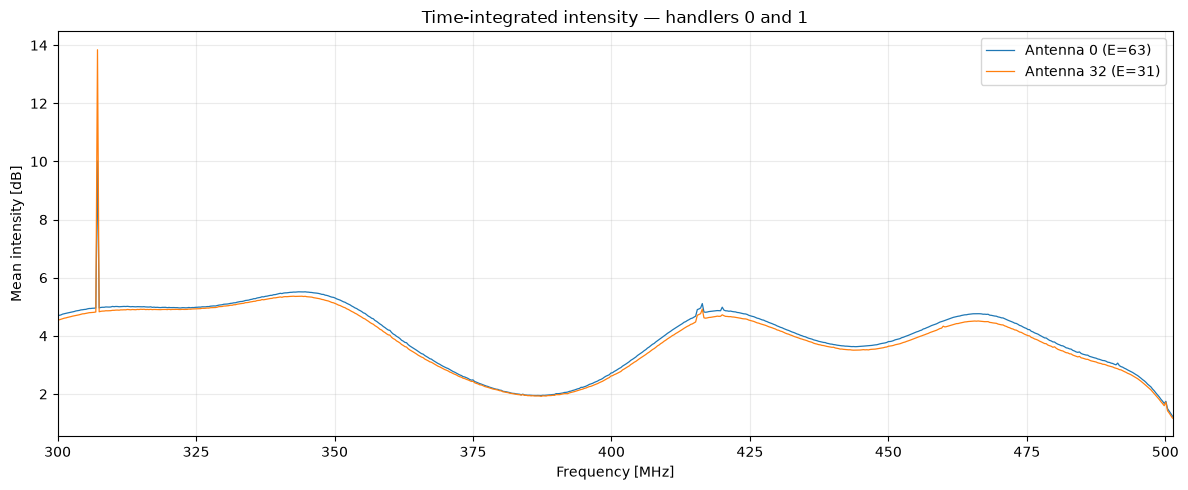

In [14]:
path = Path("/data/same_lenght_cable_take2/")

antenna_a = 0
antenna_b = 32

element_a = physical_antenna_to_element(antenna_a)
element_b = physical_antenna_to_element(antenna_b)

preview_elements = [element_a, element_b]

channels_per_handler = DEFAULT_CHANNELS       # 336
spectra_per_frame = DEFAULT_SPECTRA_PER_FRAME
elements = DEFAULT_ELEMENTS

total_channels = 2 * channels_per_handler     # 672
chunk_size = 2048
iq_order = "ri"

files_by_handler = {
    0: sorted(path.glob("*network_0_*.bin")),
    1: sorted(path.glob("*network_1_*.bin")),
}

integrated_intensity = {
    element: np.zeros(total_channels, dtype=np.float64)
    for element in preview_elements
}

total_spectra = np.zeros(2, dtype=np.int64)


for handler in (0, 1):
    handler_files = files_by_handler[handler]

    if not handler_files:
        raise RuntimeError(
            f"No files found for handler {handler}"
        )

    channel_slice = slice(
        handler * channels_per_handler,
        (handler + 1) * channels_per_handler,
    )

    for file_path in handler_files:
        frame, _, _ = read_raw_frame(
            file_path,
            spectra_per_frame,
            channels_per_handler,
            elements,
            "native"
        )

        for start in range(
            0,
            frame.shape[0],
            chunk_size,
        ):
            stop = min(
                start + chunk_size,
                frame.shape[0],
            )

            for element in preview_elements:
                voltage = decode_int4x2(
                    np.asarray(
                        frame[start:stop, :, element]
                    ),
                    iq_order,
                )

                intensity = (
                    voltage.real**2
                    + voltage.imag**2
                )

                integrated_intensity[element][
                    channel_slice
                ] += np.sum(
                    intensity,
                    axis=0,
                    dtype=np.float64,
                )

            total_spectra[handler] += stop - start

        del frame


# Normalizar cada handler por sus propios espectros
mean_intensity = {}

for element in preview_elements:
    mean_intensity[element] = np.empty(
        total_channels,
        dtype=np.float64,
    )

    for handler in (0, 1):
        channel_slice = slice(
            handler * channels_per_handler,
            (handler + 1) * channels_per_handler,
        )

        mean_intensity[element][channel_slice] = (
            integrated_intensity[element][channel_slice]
            / total_spectra[handler]
        )


# 672 canales: 300.0–501.3 MHz
frequency_mhz = (
    300.0
    + np.arange(total_channels) * 0.3
)


figure, axis = plt.subplots(figsize=(12, 5))

for antenna, element in (
    (antenna_a, element_a),
    (antenna_b, element_b),
):
    with np.errstate(
        divide="ignore",
        invalid="ignore",
    ):
        intensity_db = 10.0 * np.log10(
            mean_intensity[element]
        )

    intensity_db = np.nan_to_num(
        intensity_db,
        nan=-60.0,
        neginf=-60.0,
        posinf=0.0,
    )

    intensity_db = np.maximum(
        intensity_db,
        -60.0,
    )

    axis.plot(
        frequency_mhz,
        intensity_db,
        linewidth=0.9,
        label=f"Antenna {antenna} (E={element})",
    )

axis.set_xlabel("Frequency [MHz]")
axis.set_ylabel("Mean intensity [dB]")
axis.set_title(
    "Time-integrated intensity — handlers 0 and 1"
)
axis.set_xlim(
    frequency_mhz[0],
    frequency_mhz[-1],
)
axis.grid(alpha=0.25)
axis.legend()

figure.tight_layout()
plt.show()

Peak Amplitude: 506.45098223915176 (handler 0, antennas E=63 vs E=31)
Peak delay: 6.815592447916667 ns (handler 0, antennas E=63 vs E=31)


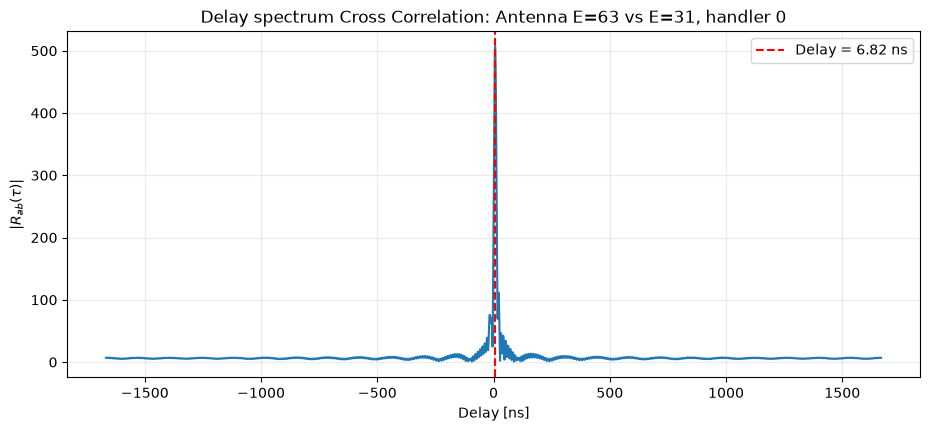

In [ ]:
plot_time_lag_xcorrelation(
    files=files,
    spectra_per_frame=DEFAULT_SPECTRA_PER_FRAME,
    channels=DEFAULT_CHANNELS,
    elements=DEFAULT_ELEMENTS,
    element_a=element_a,
    element_b=element_b,    
    iq_order="ri",
    chunk_spectra=2048,
    handler=0,
    max_lag_spectra=1000,
    spectra_per_second=300000,
    output_path=Path("time_lag_correlation.png"),
)


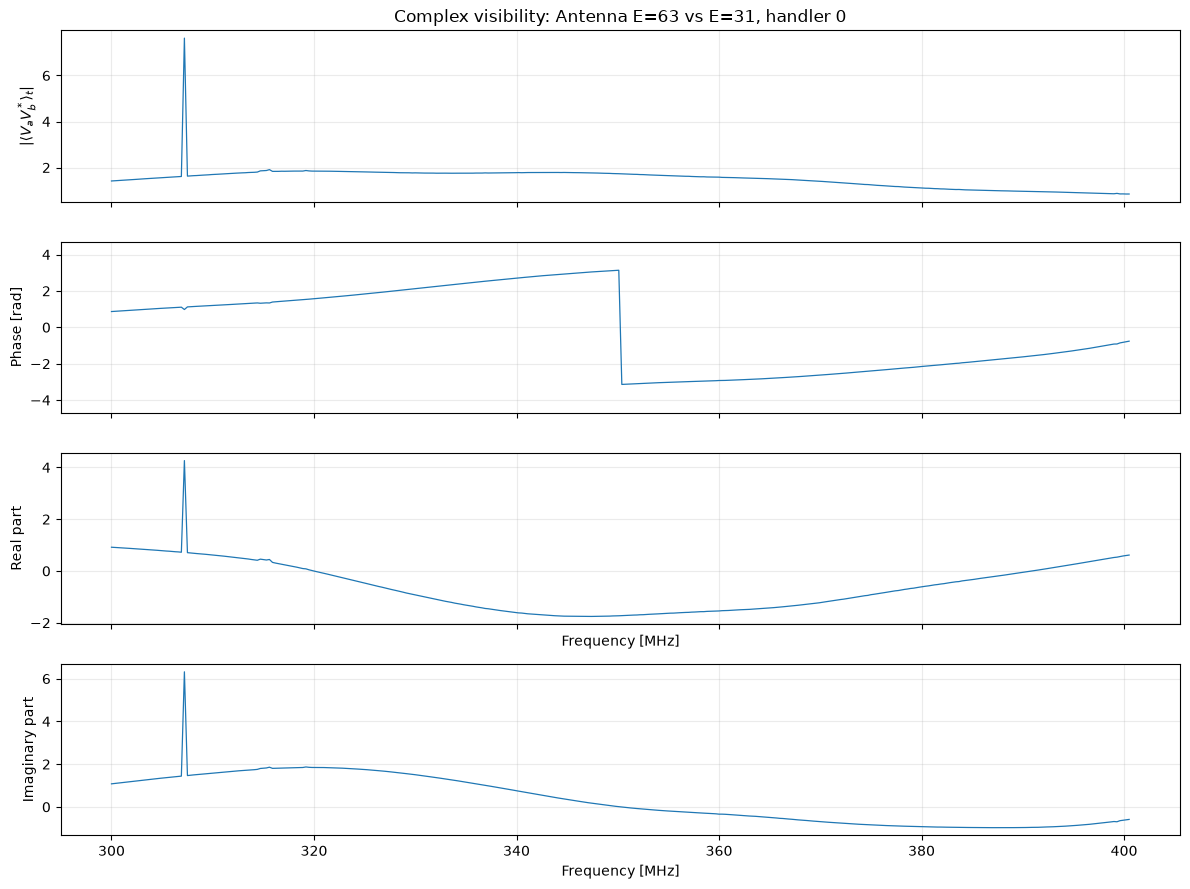

Peak Amplitude: 506.45098223915176 (handler 0, antennas E=63 vs E=31)
Peak delay: 0.0 ns (handler 0, antennas E=63 vs E=31)


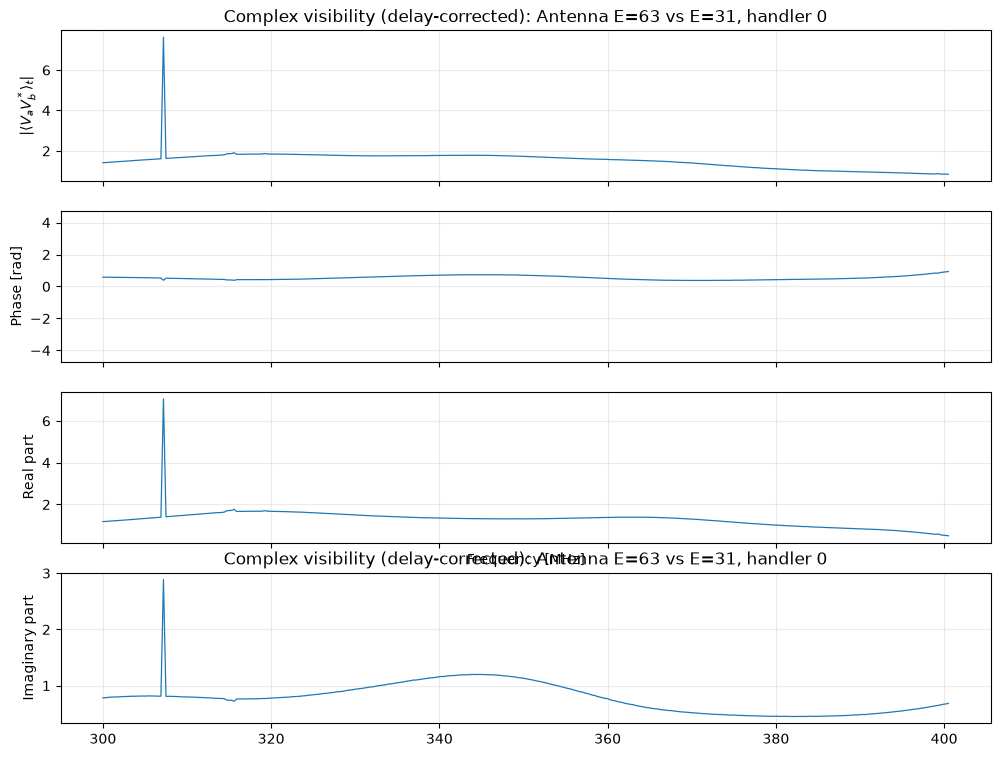

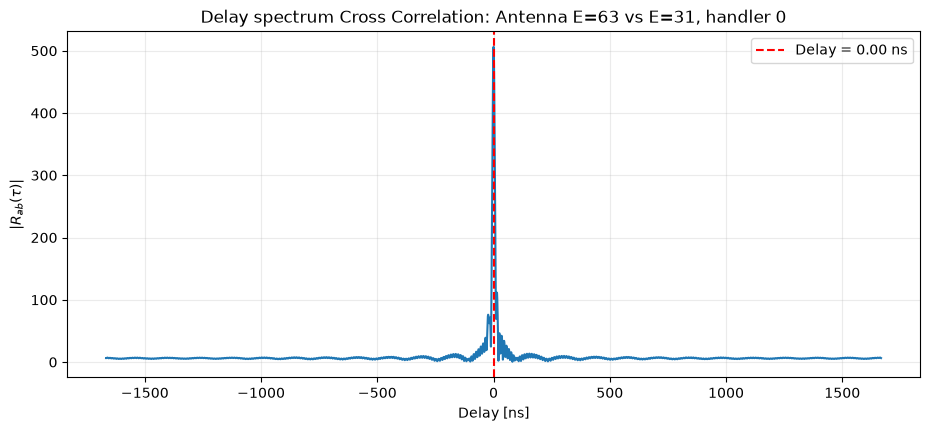

In [ ]:
plot_complex_visibility(
    files=files,
    spectra_per_frame=DEFAULT_SPECTRA_PER_FRAME,
    channels=DEFAULT_CHANNELS,
    elements=DEFAULT_ELEMENTS,
    element_a=element_a,
    element_b=element_b,
    iq_order="ri",
    chunk_spectra=2048,
    handler=0,
    tau_ns= 6.815592447916667  
)